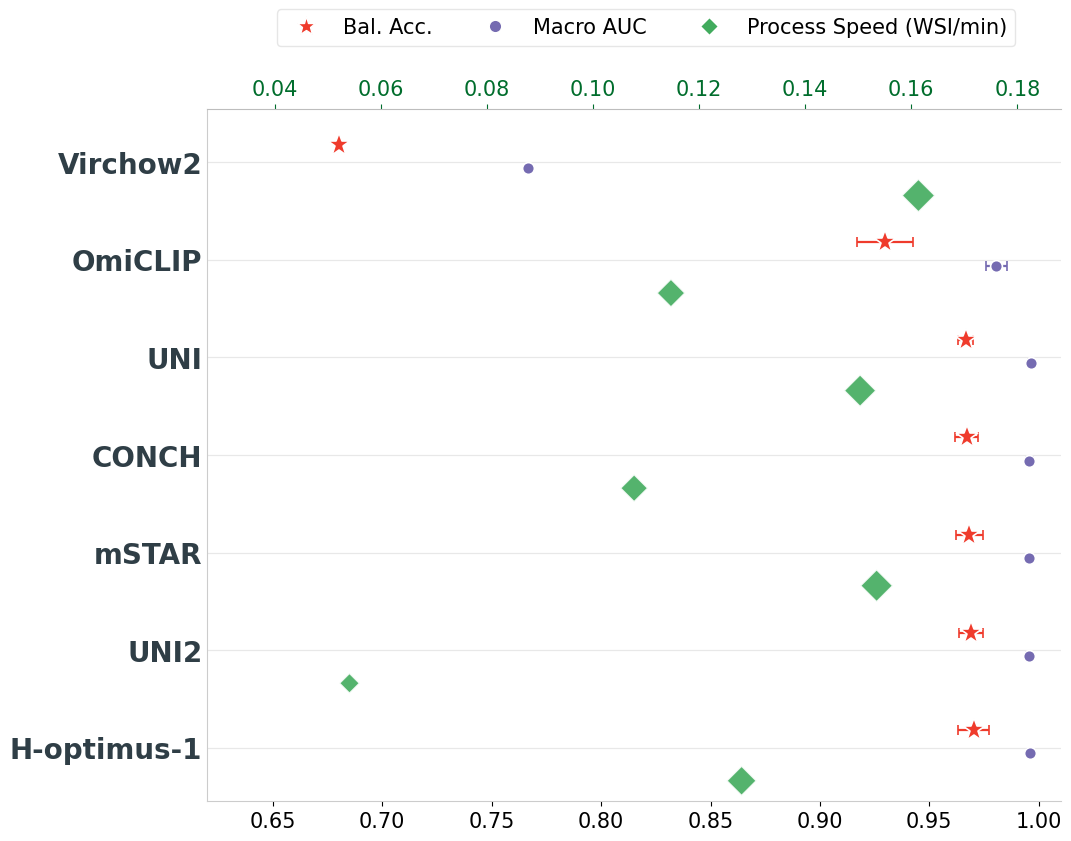

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

INPUT_CSV = "PFM/all_val_metrics_summary.csv"
OUT_FIG = "config/pfm-dot.svg"
FS = 18


plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Arial Unicode MS", "SimHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["svg.fonttype"] = "path"


def parse_stat(x):
    if pd.isna(x):
        return np.nan, 0.0
    if isinstance(x, (int, float)):
        return float(x), 0.0
    parts = str(x).replace(" ", "").split("±")
    return float(parts[0]), float(parts[1]) if len(parts) > 1 else 0.0


df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.str.strip()

rows = []
for _, r in df.iterrows():
    bacc, bacc_std = parse_stat(r["bacc"])
    auc, auc_std = parse_stat(r["macro_auc"])
    rows.append({"PFM": r["method"], "BACC": bacc, "BACC_std": bacc_std, "AUC": auc, "AUC_std": auc_std, "Speed": 60 / float(r["time(s)"])})

dfp = pd.DataFrame(rows).sort_values("BACC", ascending=True).reset_index(drop=True)

colors = {"bacc": "#ef3b2c", "auc": "#756bb1", "speed": "#41ab5d", "grid": "#e8e8e8"}
metric_min = min(dfp["BACC"].min() - dfp["BACC_std"].max(), dfp["AUC"].min() - dfp["AUC_std"].max())
xlim = (0.62, 1.01)

fig, ax = plt.subplots(figsize=(11, 8))
ax2 = ax.twiny()

y = np.arange(len(dfp))
bacc_y, auc_y, speed_y = y - 0.18, y + 0.06, y + 0.34

ax.hlines(y, *xlim, color=colors["grid"], lw=0.9, zorder=0)

err = dict(elinewidth=1.6, capsize=3.5, capthick=1.6, markeredgecolor="white", markeredgewidth=1.2, zorder=4)
ax.errorbar(dfp["BACC"], bacc_y, xerr=dfp["BACC_std"], fmt="*", color=colors["bacc"], markersize=17, **err)
ax.errorbar(dfp["AUC"], auc_y, xerr=dfp["AUC_std"], fmt="o", color=colors["auc"], markersize=8.5, **err)

smin, smax = dfp["Speed"].min(), dfp["Speed"].max()
pad = (smax - smin) * 0.25
size = 110 + 180 * (dfp["Speed"] - smin) / (smax - smin + 1e-9)

ax2.set_xlim(smin - pad, smax + pad)
ax2.scatter(dfp["Speed"], speed_y, s=size, c=colors["speed"], marker="D", edgecolors="white", linewidths=1.4, alpha=0.9, zorder=3)


ax.set_xlim(*xlim)
ax.tick_params(axis="x", labelsize=FS - 3)

ax2.tick_params(axis="x", labelsize=FS - 3, colors="#006d2c")

ax.set_yticks(y)
ax.set_yticklabels(dfp["PFM"], fontsize=FS + 2, fontfamily="DejaVu Sans", fontweight="bold", color="#2f3e46")
ax.set_ylim(len(dfp) - 0.45, -0.55)
ax.tick_params(axis="y", length=0)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax2.spines[["right", "left", "bottom"]].set_visible(False)
ax2.spines["top"].set_color("#bdbdbd")

handles = [
    Line2D([], [], marker="*", color=colors["bacc"], ls="None", markersize=14, markeredgecolor="white", label="Bal. Acc."),
    Line2D([], [], marker="o", color=colors["auc"], ls="None", markersize=9, markeredgecolor="white", label="Macro AUC"),
    Line2D([], [], marker="D", color=colors["speed"], ls="None", markersize=9, markeredgecolor="white", label="Process Speed (WSI/min)")
]

fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.6, 1.07), ncol=3, frameon=True,
           facecolor="white", edgecolor="#e0e0e0", fontsize=FS - 3)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

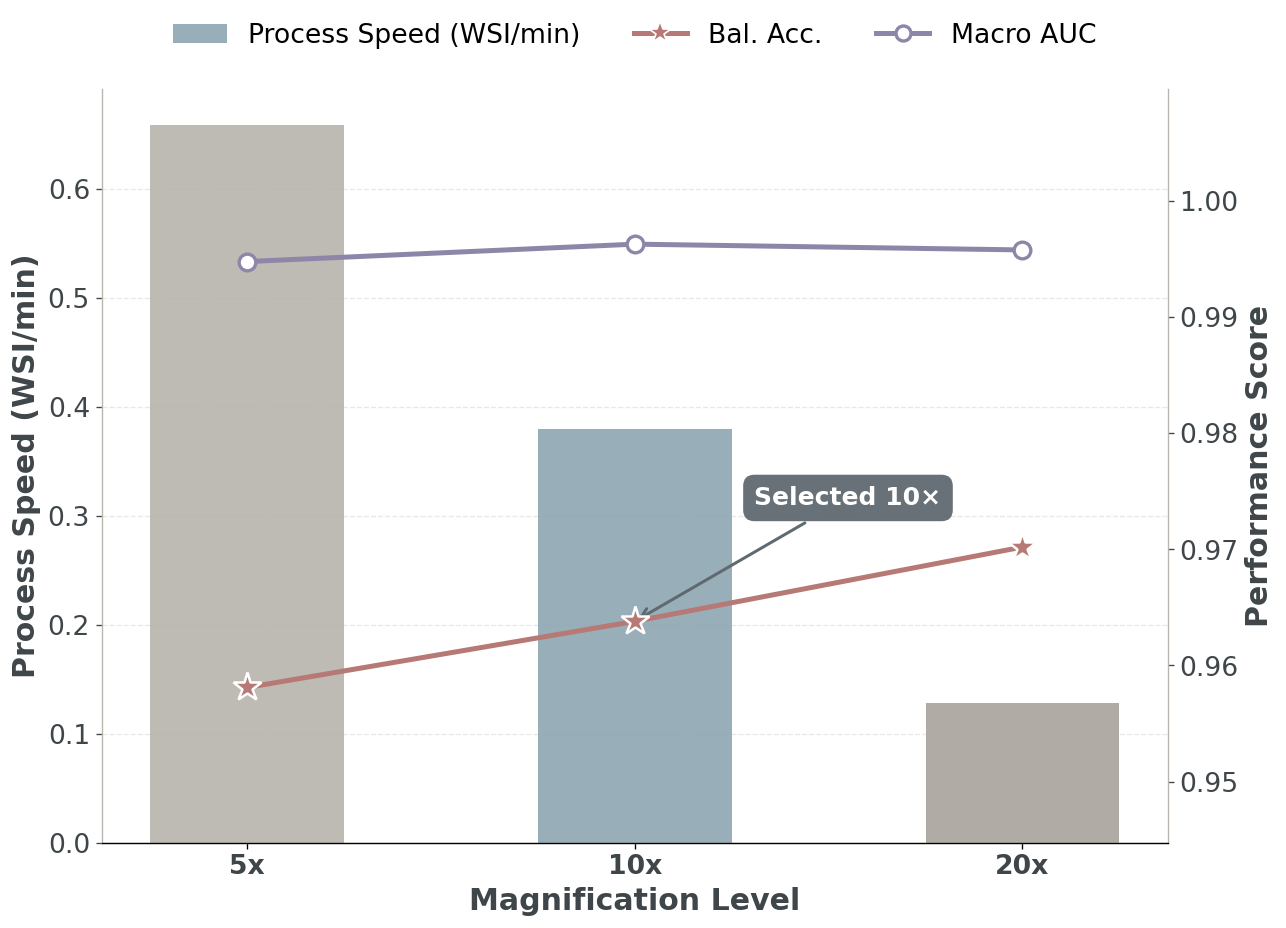

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FS = 16
FONT = {
    'label': FS + 2,
    'tick': FS,
    'legend': FS,
    'anno': FS - 1
}

plt.rcParams.update({
    'font.size': FS,
    'axes.labelsize': FONT['label'],
    'xtick.labelsize': FONT['tick'],
    'ytick.labelsize': FONT['tick'],
    'legend.fontsize': FONT['legend'],
    'axes.unicode_minus': False,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

def mean(x):
    if pd.isna(x): return 0.0
    return float(str(x).split('±')[0])

df = pd.read_csv('Mag/all_val_metrics_summary.csv')
for c in ['bacc', 'macro_auc', 'time(s)']:
    df[c] = df[c].apply(mean)

df['speed'] = 60 / df['time(s)']
df['sort_val'] = df['method'].str.extract(r'(\d+)').astype(int)
df = df.sort_values('sort_val').reset_index(drop=True)

BAR = ['#B8B5AD', '#8FA7B3', '#AAA59D']
BACC = '#B77975'
AUC = '#8E86A8'
TEXT = '#3F464A'
GRID = '#E6E2DD'
SPINE = '#B9B4AD'

fig, ax1 = plt.subplots(figsize=(11, 7), dpi=120, facecolor='white')
x = np.arange(len(df))

ax1.bar(x, df['speed'], color=BAR[:len(df)], width=0.5, alpha=0.92, zorder=2)
ax1.set_xlabel('Magnification Level', fontsize=FONT['label'], color=TEXT, fontweight='bold')
ax1.set_ylabel('Inference Speed (WSI/min)', fontsize=FONT['label'], color=TEXT, fontweight='bold')
ax1.set_xticks(x, df['method'], fontsize=FONT['tick'], fontweight='bold', color=TEXT)
ax1.tick_params(axis='y', labelsize=FONT['tick'], colors=TEXT)
ax1.grid(axis='y', linestyle='--', color=GRID, alpha=0.8, zorder=1)

for s in ['top', 'right']:
    ax1.spines[s].set_visible(False)
ax1.spines['left'].set_color(SPINE)
ax1.spines['bottom'].set_color(SPINE)

ax2 = ax1.twinx()
ymin = min(df['bacc'].min(), df['macro_auc'].min())
ymax = max(df['bacc'].max(), df['macro_auc'].max())
m = max((ymax - ymin) * 0.35, 0.01)
ax2.set_ylim(ymin - m, ymax + m)

ax2.plot(x, df['bacc'], color=BACC, marker='*', markersize=18, linewidth=3.0, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
ax2.plot(x, df['macro_auc'], color=AUC, marker='o', markersize=10, linewidth=3.0, markerfacecolor='white', markeredgewidth=2, zorder=5)

ax2.set_ylabel('Performance Score', fontsize=FONT['label'], color=TEXT, fontweight='bold')
ax2.tick_params(axis='y', labelsize=FONT['tick'], colors=TEXT)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_color(SPINE)

target = df['method'].astype(str).str.contains('10')
if target.any():
    i = df.index[target][0]
    ax2.annotate('Selected 10×', xy=(i, df.loc[i, 'bacc']), xytext=(i + 0.55, df.loc[i, 'bacc'] + m * 0.75),
                 fontsize=FONT['anno'], fontweight='bold', color='white', ha='center',
                 bbox=dict(boxstyle='round,pad=0.45', fc='#5F6970', ec='none', alpha=0.95),
                 arrowprops=dict(arrowstyle='->', color='#5F6970', lw=1.8))

handles = [
    Patch(facecolor=BAR[1], alpha=0.92, label='Process Speed (WSI/min)'),
    Line2D([], [], color=BACC, marker='*', markersize=14, lw=3.0, markeredgecolor='white', label='Bal. Acc.'),
    Line2D([], [], color=AUC, marker='o', markersize=9, lw=3.0, markerfacecolor='white', markeredgewidth=2, label='Macro AUC')
]

ax1.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.55, 1.12), ncol=3, frameon=False, fontsize=FONT['legend'])

plt.tight_layout()
plt.savefig('config/mag_tradeoff.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

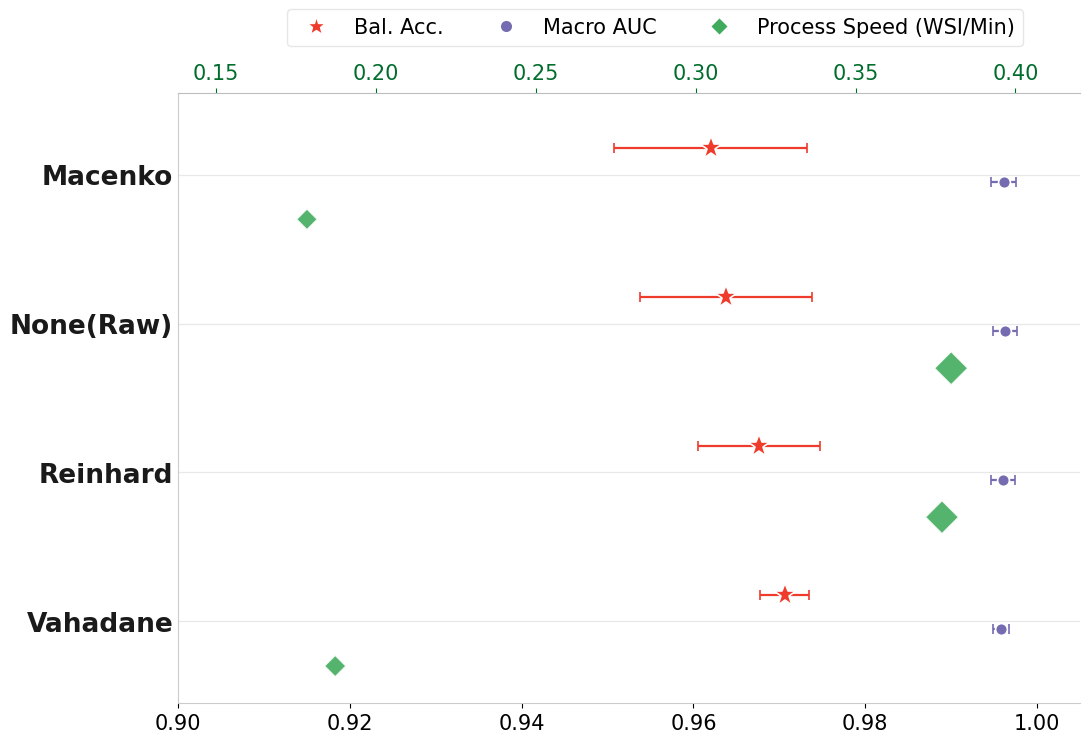

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

INPUT_CSV = "Stains/all_val_metrics_summary.csv"
OUT_FIG = "config/stains-dot.svg"
FS = 18

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans", "Arial Unicode MS", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False


def parse_stat(x):
    if pd.isna(x):
        return np.nan, 0.0
    if isinstance(x, (int, float)):
        return float(x), 0.0
    v = str(x).replace(" ", "").split("±")
    return float(v[0]), float(v[1]) if len(v) > 1 else 0.0


df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.str.strip()

rows = []
for _, r in df.iterrows():
    bacc, bacc_std = parse_stat(r["bacc"])
    auc, auc_std = parse_stat(r["macro_auc"])
    rows.append({"Method": r["method"], "BACC": bacc, "BACC_std": bacc_std, "AUC": auc, "AUC_std": auc_std, "Speed": 60 / float(r["time(s)"])})

dfp = pd.DataFrame(rows).sort_values("BACC", ascending=True).reset_index(drop=True)

C = {"bacc": "#ef3b2c", "auc": "#756bb1", "speed": "#41ab5d", "grid": "#e8e8e8", "text": "#1a1a1a"}

metric_min = min((dfp["BACC"] - dfp["BACC_std"]).min(), (dfp["AUC"] - dfp["AUC_std"]).min())
xlim = (max(0.90, 0.85), 1.005)

fig, ax = plt.subplots(figsize=(11, 7))
ax2 = ax.twiny()

y = np.arange(len(dfp))
bacc_y, auc_y, speed_y = y - 0.18, y + 0.05, y + 0.30

ax.hlines(y, *xlim, color=C["grid"], lw=0.9, zorder=0)

err = dict(elinewidth=1.6, capsize=3.5, capthick=1.6, markeredgecolor="white", markeredgewidth=1.2, zorder=4)
ax.errorbar(dfp["BACC"], bacc_y, xerr=dfp["BACC_std"], fmt="*", color=C["bacc"], markersize=17, **err)
ax.errorbar(dfp["AUC"], auc_y, xerr=dfp["AUC_std"], fmt="o", color=C["auc"], markersize=8.5, **err)

smin, smax = dfp["Speed"].min(), dfp["Speed"].max()
pad = (smax - smin) * 0.20
size = 120 + 180 * (dfp["Speed"] - smin) / (smax - smin + 1e-9)

ax2.set_xlim(smin - pad, smax + pad)
ax2.scatter(dfp["Speed"], speed_y, s=size, c=C["speed"], marker="D", edgecolors="white", linewidths=1.4, alpha=0.9, zorder=3)


ax.set_xlim(*xlim)
ax.tick_params(axis="x", labelsize=FS - 3)

ax2.tick_params(axis="x", labelsize=FS - 3, colors="#006d2c")

ax.set_yticks(y)
ax.set_yticklabels(dfp["Method"], fontsize=FS + 1, fontweight="bold", color=C["text"])
ax.set_ylim(len(dfp) - 0.45, -0.55)
ax.tick_params(axis="y", length=0)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax2.spines[["right", "left", "bottom"]].set_visible(False)
ax2.spines["top"].set_color("#bdbdbd")

handles = [
    Line2D([], [], marker="*", color=C["bacc"], ls="None", markersize=14, markeredgecolor="white", label="Bal. Acc."),
    Line2D([], [], marker="o", color=C["auc"], ls="None", markersize=9, markeredgecolor="white", label="Macro AUC"),
    Line2D([], [], marker="D", color=C["speed"], ls="None", markersize=9, markeredgecolor="white", label="Process Speed (WSI/Min)")
]

fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.6, 1.07), ncol=3,
           frameon=True, facecolor="white", edgecolor="#e0e0e0", fontsize=FS - 3)

Path(OUT_FIG).parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()